In [53]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt

# Getting the data from a csv file downloaded from kaggle
df = pd.read_csv("data.csv")  # Get the full dataset from the file data.csv

# Cleaning the data
df = df.loc[df["Winner"].astype(str) != "Draw"]  # Eliminates Drawing from the dataset
# df['Winner'].mask(df['Winner'] == "Red", 1) #setting Red to 1
# df['Winner'].mask(df['Winner'] == "Blue", 0) #Setting Blue to 0
# df['B_Stance'].mask(df['B_Stance'] == "Orthodox", 1) #setting blue orthodox to 1
# df['B_Stance'].mask(df['B_Stance'] == "Southpaw", 0) #Setting blue southpaw to 0
# df['R_Stance'].mask(df['R_Stance'] == "Orthodox", 1) #setting red orthodox to 1
# df['R_Stance'].mask(df['R_Stance'] == "Southpaw", 0) #Setting red southpaw to 0
df.loc[df["Winner"].astype(str) == "Red"] = 1  # setting Red to 1
df.loc[df["Winner"].astype(str) == "Blue"] = 0  # Setting Blue to 0
df.loc[df["B_Stance"].astype(str) == "Orthodox"] = 1  # setting blue orthodox to 1
df.loc[df["B_Stance"].astype(str) == "Southpaw"] = 0  # Setting blue southpaw to 0
df.loc[df["R_Stance"].astype(str) == "Orthodox"] = 1  # setting red orthodox to 1
df.loc[df["R_Stance"].astype(str) == "Southpaw"] = 0  # Setting red southpaw to 0
# upon further research, this all could have been done with pandas.get_dummies(), but this method also works.

excluded_cols = [  # list of irrelevant columns
    "R_fighter",
    "B_fighter",
    "Referee",
    "date",
    "location",
    "title_bout",
    "weight_class",
    "B_win_by_Decision_Majority",
    "B_win_by_Decision_Split",
    "B_win_by_Decision_Unanimous",
    "B_win_by_TKO_Doctor_Stoppage",
    "B_Weight_lbs",
    "R_win_by_Decision_Majority",
    "R_win_by_Decision_Split",
    "R_win_by_Decision_Unanimous",
    "R_win_by_TKO_Doctor_Stoppage",
    "R_Weight_lbs",
]
new_df = df.drop(excluded_cols, axis=1)  # Dropping excluded columns
new_df = new_df.dropna()  # dropping null values
# Dataset is now cleaned, with the first row being our y_data
# and the rest being our x data
y_vals = new_df.pop("Winner")
new_df = new_df.astype(float)  # converting the objects to floats for use in pytorch

# For future reference, this cleaning could have been a lot simpler if I started off with pandas.get_dummies() and then going df = df.astype(float). However, what has been written works despite its inefficiency


# Converting to float32 tensors to make them work with pytorch
y_vals = torch.tensor(y_vals, dtype=torch.long)
x_vals = torch.tensor(new_df.values, dtype=torch.float32)


# Splitting into testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    x_vals, y_vals, test_size=0.3, random_state=42
)


/tmp/ipykernel_2840/242383987.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["Winner"].astype(str) == "Red"] = 1  # setting Red to 1


In [54]:
# Now we will define our pytorch class
class MLP_3(nn.Module):
    def __init__(self, hidden_1, hidden_2, hidden_3, input_size=126, output_size=10):
        super(MLP_3, self).__init__()
        self.linear_1 = nn.Linear(input_size, hidden_1)
        self.linear_2 = nn.Linear(hidden_1, hidden_2)
        self.linear_3 = nn.Linear(hidden_2, hidden_3)
        self.linear_4 = nn.Linear(hidden_3, output_size)

    def forward(self, x):
        out = self.linear_1(x)
        out = F.relu(out)
        out = self.linear_2(out)
        out = F.relu(out)
        out = self.linear_3(out)
        out = F.sigmoid(out)
        out = self.linear_4(out)
        return out

Now that we have our Data and our model class, we can begin implementation of the three hidden layer MLP

In [55]:
# Example one: standard layer sizing of previous*2/3 + output
# This is meant to be the most basic, as it is our first implementation
# The following code is taken from assignment 9 - nothing new here
model_1 = MLP_3(95, 73, 59)
n_epochs_mlp = 2000
learning_rate = 0.1
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_1.parameters(), lr=learning_rate)
train_losses_mlp = np.zeros((n_epochs_mlp,))
test_losses_mlp = np.zeros((n_epochs_mlp,))
accuracies_mlp = np.zeros((n_epochs_mlp,))

for epoch in range(n_epochs_mlp):
    optimizer.zero_grad()
    model_1.train()
    outputs = model_1(X_train)
    loss = criterion(outputs, y_train)
    train_losses_mlp[epoch] = loss.item()

    with torch.no_grad():
        model_1.eval()
        test_outputs = model_1(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses_mlp[epoch] = test_loss.item()
        accuracies_mlp[epoch] = (
            torch.sum(test_outputs.argmax(dim=1) == y_test) / y_test.shape[0]
        ).item()
    loss.backward()
    optimizer.step()

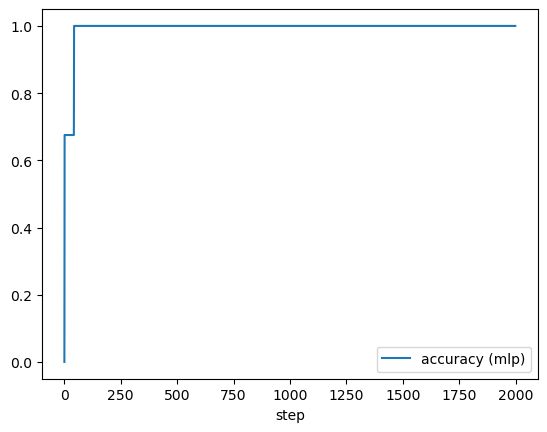

In [56]:
plt.figure()
plt.plot(range(n_epochs_mlp), accuracies_mlp, label='accuracy (mlp)')
plt.xlabel('step')
plt.legend()
plt.show()